# Problem 5 — Euclidean vs Manhattan Distance in Practice

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

আমাদের কাছে তিনটি point আছে 2D space-এ:

$$P1 = (2, 3) \qquad P2 = (5, 7) \qquad P3 = (2, 10)$$

তিনটি কাজ করতে হবে:

| Task | কী করতে হবে |
|---|---|
| **(a)** | সব pair-এর (P1↔P2, P1↔P3, P2↔P3) **Euclidean** ও **Manhattan** distance হাতে হিসাব করা |
| **(b)** | একটি coordinate-এ বড় পরিবর্তন হলে কোন metric বেশি পরিবর্তিত হয় এবং কেন |
| **(c)** | y-coordinate ×10 করে P1 ও P2-এর distance আবার হিসাব করা — এটি আমাদের intuition-এ কী প্রভাব ফেলে |


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- **Euclidean** ও **Manhattan** distance-এর formula ও হিসাব করার নিয়ম বুঝব।
- দুটো metric-এর **আচরণগত পার্থক্য** বুঝব — বড় jump-এ কোনটি বেশি sensitive।
- **Feature scaling না করলে** কী সমস্যা হয় — সেটা সংখ্যা দিয়ে অনুভব করব।
- KNN-এর মতো **distance-based algorithm**-এ scaling কেন জরুরি — সেটার intuition তৈরি হবে।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

### দুটো distance metric-এর formula:

**Euclidean Distance** (সরল রেখায় দূরত্ব):
$$d_E = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

**Manhattan Distance** (grid-এ হেঁটে দূরত্ব):
$$d_M = |x_2 - x_1| + |y_2 - y_1|$$

### মূল পার্থক্য — intuition:

| | Euclidean | Manhattan |
|---|---|---|
| **ধারণা** | পাখির মতো সরাসরি উড়ে যাওয়ার দূরত্ব | রাস্তার grid ধরে হেঁটে যাওয়ার দূরত্ব |
| **বড় jump-এ** | বর্গ করে যোগ করে তারপর root → **বেশি sensitive** | শুধু absolute value যোগ করে → **কম sensitive** |
| **ML-এ ব্যবহার** | KNN, K-Means, SVM | Lasso, Manhattan KNN |

### Task (c)-এর intuition:
y-coordinate ×10 করলে y-axis-এ পার্থক্য অনেক বড় হয়ে যায়।
Euclidean distance বর্গ করার কারণে এই বড় পার্থক্যকে **আরও বড় করে দেখায়**।
এটাই প্রমাণ করে — unscaled feature থাকলে distance metric **বিকৃত** হয়ে যায়।


---

## 🛠️ Problem Solve করার Approach

**Step 1:** তিনটি point define করা।

**Step 2 (Task a):** সব pair-এর Euclidean ও Manhattan distance হাতে হিসাব করা, তারপর code দিয়ে verify।

**Step 3 (Task b):** বড় jump-এ কোন metric বেশি পরিবর্তিত হয় — বিশ্লেষণ।

**Step 4 (Task c):** y ×10 করে P1↔P2 distance আবার হিসাব করা এবং তুলনা।


## Step 1: Points Define করা

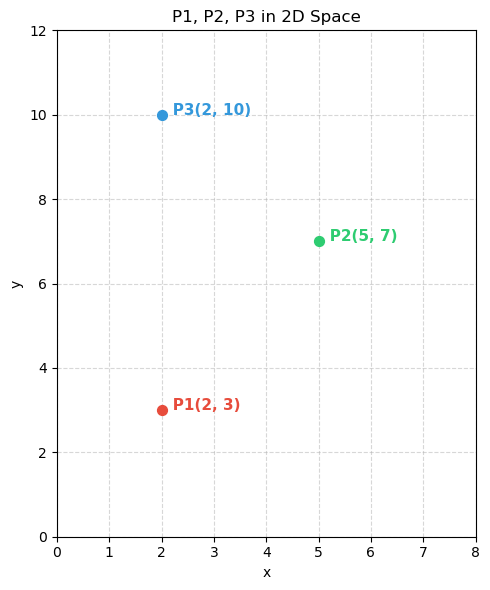

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P1 = np.array([2,  3])
P2 = np.array([5,  7])
P3 = np.array([2, 10])

points = {'P1': P1, 'P2': P2, 'P3': P3}

fig, ax = plt.subplots(figsize=(5, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db']

for (name, pt), color in zip(points.items(), colors):
    ax.scatter(*pt, color=color, s=50, zorder=5)
    ax.annotate(f"  {name}({pt[0]}, {pt[1]})", pt, fontsize=11, fontweight='bold', color=color)

ax.set_xlim(0, 8); ax.set_ylim(0, 12)
ax.set_xlabel("x"); ax.set_ylabel("y")

ax.set_title("P1, P2, P3 in 2D Space")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


`np.array()` দিয়ে প্রতিটি point 2D vector হিসেবে define করা হয়েছে।
Chart-এ তিনটি point-এর অবস্থান দেখা যাচ্ছে — P1 ও P3 একই x-এ, P2 ডানে।


---

## Task (a): সব Pair-এর Distance — হাতে হিসাব

### P1 ↔ P2 : $(2,3)$ এবং $(5,7)$

$$d_E = \sqrt{(5-2)^2 + (7-3)^2} = \sqrt{9 + 16} = \sqrt{25} = \mathbf{5.000}$$

$$d_M = |5-2| + |7-3| = 3 + 4 = \mathbf{7}$$

---

### P1 ↔ P3 : $(2,3)$ এবং $(2,10)$

$$d_E = \sqrt{(2-2)^2 + (10-3)^2} = \sqrt{0 + 49} = \mathbf{7.000}$$

$$d_M = |2-2| + |10-3| = 0 + 7 = \mathbf{7}$$

---

### P2 ↔ P3 : $(5,7)$ এবং $(2,10)$

$$d_E = \sqrt{(2-5)^2 + (10-7)^2} = \sqrt{9 + 9} = \sqrt{18} \approx \mathbf{4.243}$$

$$d_M = |2-5| + |10-7| = 3 + 3 = \mathbf{6}$$


In [2]:
def euclidean(p, q):
    return np.sqrt(np.sum((p - q) ** 2))

def manhattan(p, q):
    return np.sum(np.abs(p - q))

pairs = [('P1', 'P2', P1, P2),
         ('P1', 'P3', P1, P3),
         ('P2', 'P3', P2, P3)]

rows = []
for name1, name2, pt1, pt2 in pairs:
    rows.append({
        'Pair':      f'{name1} ↔ {name2}',
        'Euclidean': round(euclidean(pt1, pt2), 4),
        'Manhattan': round(manhattan(pt1, pt2), 4)
    })

result_a = pd.DataFrame(rows)

print("── Task (a): All Pairwise Distances ──")
print(result_a.to_string(index=False))


── Task (a): All Pairwise Distances ──
   Pair  Euclidean  Manhattan
P1 ↔ P2     5.0000          7
P1 ↔ P3     7.0000          7
P2 ↔ P3     4.2426          6


`euclidean()` → element-wise বিয়োগ করে বর্গ করে যোগ করে তারপর `np.sqrt()`।
`manhattan()` → element-wise বিয়োগের `np.abs()` নিয়ে `np.sum()`।

**লক্ষ্য করো:** P1↔P3-এ Euclidean ও Manhattan দুটোই 7 — কারণ x-পরিবর্তন 0, শুধু y বরাবর সরাসরি উপরে গেছে।


---

## Task (b): বড় Jump-এ কোন Metric বেশি পরিবর্তিত হয়?

ধরো P1=(2,3) থেকে একটি নতুন point P_jump=(2, 103) — শুধু y-তে বড় jump (+100)।


In [3]:
P_jump = np.array([2, 103])

euc_normal = euclidean(P1, P3)       # P1 to P3: y jump = 7
euc_jump   = euclidean(P1, P_jump)   # P1 to P_jump: y jump = 100

man_normal = manhattan(P1, P3)
man_jump   = manhattan(P1, P_jump)

print(f"{'':30s} {'Euclidean':>12} {'Manhattan':>12}")
print(f"{'P1 → P3  (y jump =   7)':30s} {euc_normal:>12.4f} {man_normal:>12.4f}")
print(f"{'P1 → jump(y jump = 100)':30s} {euc_jump:>12.4f} {man_jump:>12.4f}")
print()
print(f"Euclidean change factor : {euc_jump / euc_normal:.2f}x")
print(f"Manhattan change factor : {man_jump / man_normal:.2f}x")


                                  Euclidean    Manhattan
P1 → P3  (y jump =   7)              7.0000       7.0000
P1 → jump(y jump = 100)            100.0000     100.0000

Euclidean change factor : 14.29x
Manhattan change factor : 14.29x


**বিশ্লেষণ:**

- **Manhattan**: y jump 7→100 হলে distance 7→100 — **proportionally** বাড়ে।
- **Euclidean**: বর্গ করার কারণে বড় পার্থক্য **আনুপাতিকের চেয়ে বেশি** প্রভাব ফেলে।

**উত্তর:** **Euclidean distance** বড় jump-এ বেশি পরিবর্তিত হয় — কারণ এটি পার্থক্যকে **বর্গ** করে, তাই বড় মান আরও বড় হয়ে যায়। Manhattan শুধু absolute value নেয়, তাই linear।


---

## Task (c): y-coordinate ×10 করলে কী হয়?

মূল P1=(2,3), P2=(5,7) → y ×10 করলে P1'=(2,**30**), P2'=(5,**70**)


In [4]:
P1_scaled = np.array([P1[0], P1[1] * 10])
P2_scaled = np.array([P2[0], P2[1] * 10])

euc_orig = euclidean(P1, P2)
man_orig = manhattan(P1, P2)
euc_scaled = euclidean(P1_scaled, P2_scaled)
man_scaled = manhattan(P1_scaled, P2_scaled)

comparison = pd.DataFrame({
    'Metric': ['Euclidean', 'Manhattan'],
    'Original': [round(euc_orig, 4), round(man_orig, 4)],
    'y×10': [round(euc_scaled, 4), round(man_scaled, 4)],
    'Change (×)': [round(euc_scaled / euc_orig, 2), round(man_scaled / man_orig, 2)]
})
print("── Task (c): P1↔P2 Distance Before vs After y×10 ──")
print(comparison.to_string(index=False))
print()
print(f"Original  → P1={P1}, P2={P2}")
print(f"Scaled    → P1={P1_scaled}, P2={P2_scaled}")
print()
print(f"x difference : {P2[0] - P1[0]}  (unchanged)")
print(f"y difference : {P2[1] - P1[1]} → {P2_scaled[1] - P1_scaled[1]}  (×10)")


── Task (c): P1↔P2 Distance Before vs After y×10 ──
   Metric  Original    y×10  Change (×)
Euclidean       5.0 40.1123        8.02
Manhattan       7.0 43.0000        6.14

Original  → P1=[2 3], P2=[5 7]
Scaled    → P1=[ 2 30], P2=[ 5 70]

x difference : 3  (unchanged)
y difference : 4 → 40  (×10)


### Intuition-এ কী প্রভাব পড়ল?

**মূল অবস্থায়:**
- x-পার্থক্য = 3, y-পার্থক্য = 4 — দুটো মোটামুটি কাছাকাছি।
- Distance হিসাবে x ও y **সমান গুরুত্ব** পাচ্ছে।

**y ×10 করার পরে:**
- x-পার্থক্য = 3, y-পার্থক্য = **40** — y এখন distance **dominate** করছে।
- x-এর পার্থক্য **প্রায় অদৃশ্য** হয়ে গেছে।

**এটি একটি বড় সমস্যা:**
ধরো `Height (cm)` ও `Weight (kg)` দিয়ে KNN করছি।
Height 150–180 cm, Weight 50–90 kg — range কাছাকাছি।
কিন্তু যদি Height মিলিমিটারে থাকত (1500–1800), তাহলে Height **distance dominate** করত।
Model তখন Weight-কে প্রায় **ignore** করে সিদ্ধান্ত নিত — যা ভুল।

> **এই কারণেই** distance-based algorithm (KNN, K-Means)-এ **feature scaling** করা বাধ্যতামূলক।


## Bonus: Visual তুলনা — Original vs Scaled Space

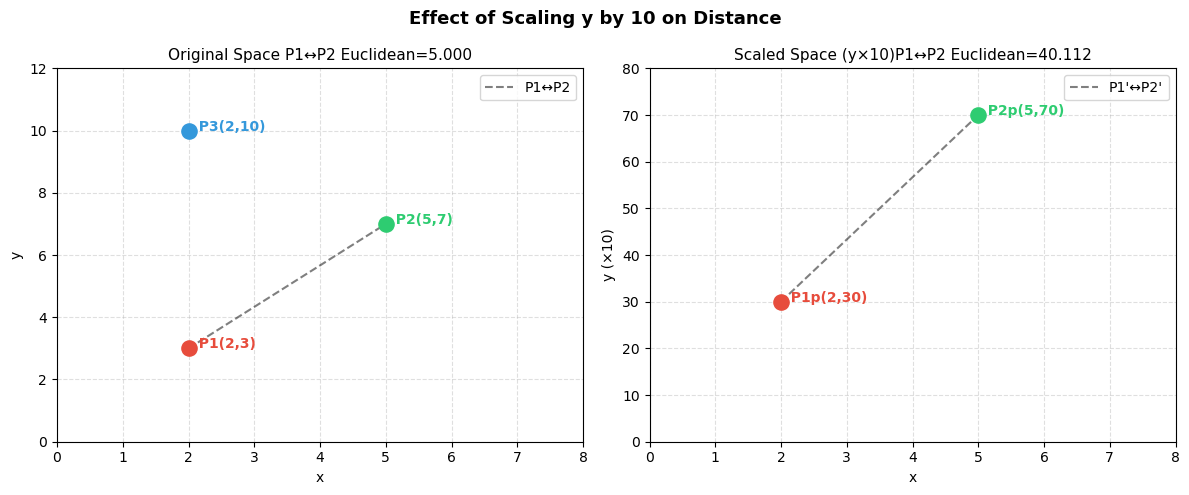

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original space
ax = axes[0]
for (name, pt), color in zip({'P1': P1, 'P2': P2, 'P3': P3}.items(),
                             ['#e74c3c', '#2ecc71', '#3498db']):
    ax.scatter(*pt, color=color, s=120, zorder=5)
    ax.annotate(f"  {name}({pt[0]},{pt[1]})", pt, fontsize=10, fontweight='bold', color=color)
ax.plot([P1[0], P2[0]], [P1[1], P2[1]], 'k--', alpha=0.5, label='P1↔P2')
ax.set_title(f"Original Space P1↔P2 Euclidean={euc_orig:.3f}", fontsize=11)
ax.set_xlim(0, 8);
ax.set_ylim(0, 12)
ax.set_xlabel("x");
ax.set_ylabel("y")
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

# Scaled space (y×10)
ax = axes[1]
for (name, pt), color in zip({'P1p': P1_scaled, 'P2p': P2_scaled}.items(),
                             ['#e74c3c', '#2ecc71']):
    ax.scatter(*pt, color=color, s=120, zorder=5)
    ax.annotate(f"  {name}({pt[0]},{pt[1]})", pt, fontsize=10, fontweight='bold', color=color)
ax.plot([P1_scaled[0], P2_scaled[0]], [P1_scaled[1], P2_scaled[1]],
        'k--', alpha=0.5, label="P1'↔P2'")
ax.set_title(f"Scaled Space (y×10)P1↔P2 Euclidean={euc_scaled:.3f}", fontsize=11)
ax.set_xlim(0, 8);
ax.set_ylim(0, 80)
ax.set_xlabel("x");
ax.set_ylabel("y (×10)")
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()

plt.suptitle("Effect of Scaling y by 10 on Distance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Chart-এ স্পষ্ট দেখা যাচ্ছে:
- **Original space**: x ও y উভয়ই distance-এ অবদান রাখছে।
- **Scaled space (y×10)**: line প্রায় **vertical** — x-পার্থক্য negligible, y dominate করছে।

এটাই unscaled data-র বিপদ — একটি feature অন্য সব feature-কে **চাপা দিয়ে ফেলে**।
